<a href="https://colab.research.google.com/github/karman07/3d_editing/blob/main/malaria_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Malaria Prediction using CNN (MobileNetV2)

This notebook provides an end-to-end workflow for detecting Malaria in cell images. The notebook is broken down into:
1. **Configuration and Setup**
2. **Exploratory Data Analysis (EDA)**
3. **Feature Extraction & Data Augmentation**
4. **Building the CNN Model (MobileNetV2 Transfer Learning)**
5. **Training and Evaluation**
6. **Inference (Single Image Prediction)**

In [6]:
!unzip -o colab_malaria_project.zip -d ./

Streaming output truncated to the last 5000 lines.
 extracting: ./cell_images/Uninfected/C188P149ThinF_IMG_20151203_134419_cell_148.png  
 extracting: ./cell_images/Uninfected/C132P93ThinF_IMG_20151004_152045_cell_13.png  
 extracting: ./cell_images/Uninfected/C12NThinF_IMG_20150614_124301_cell_260.png  
 extracting: ./cell_images/Uninfected/C50P11thinF_IMG_20150724_115603_cell_117.png  
 extracting: ./cell_images/Uninfected/C125P86ThinF_IMG_20151004_102619_cell_35.png  
 extracting: ./cell_images/Uninfected/C46P7ThinF_IMG_20151130_210743_cell_3.png  
 extracting: ./cell_images/Uninfected/C166P127ThinF_IMG_20151117_195030_cell_140.png  
 extracting: ./cell_images/Uninfected/C217ThinF_IMG_20151106_141326_cell_183.png  
 extracting: ./cell_images/Uninfected/C157P118ThinF_IMG_20151115_163759_cell_93.png  
 extracting: ./cell_images/Uninfected/C72P33_ThinF_IMG_20150815_104923_cell_27.png  
 extracting: ./cell_images/Uninfected/C165P126ThinF_IMG_20151117_164432_cell_130.png  
 extracting: .

In [5]:
import os

zip_file_path = 'colab_malaria_project.zip'
if os.path.exists(zip_file_path):
    print(f"File '{zip_file_path}' exists.")
    print(f"File size: {os.path.getsize(zip_file_path)} bytes")
else:
    print(f"File '{zip_file_path}' does not exist. Please ensure it is uploaded correctly.")


File 'colab_malaria_project.zip' exists.
File size: 119537664 bytes


In [7]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

DATA_DIR = './cell_images'
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 15
MODEL_PATH = 'malaria_main_model.keras'

## 1. Exploratory Data Analysis (EDA)

--- Exploratory Data Analysis ---
Classes found: ['Uninfected', 'Parasitized']


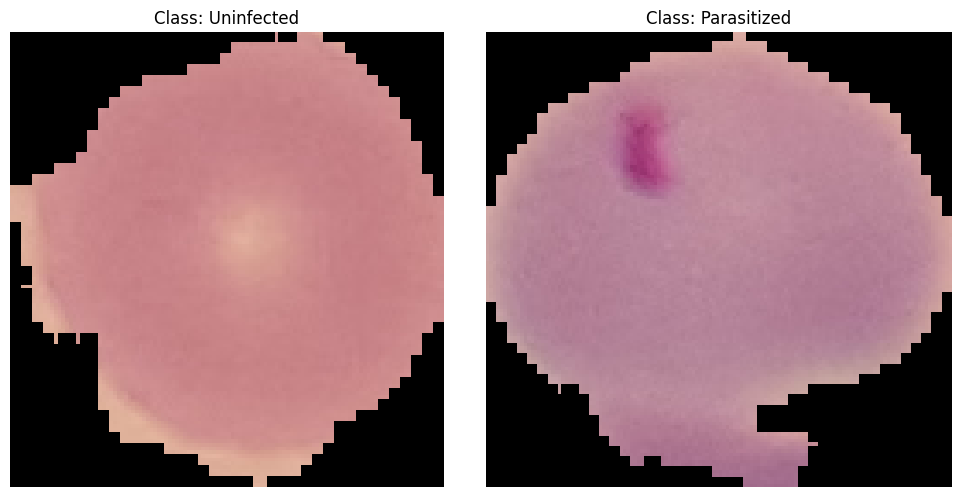

In [8]:
def perform_eda(data_dir):
    print("--- Exploratory Data Analysis ---")
    if not os.path.exists(data_dir):
        print("Data not found at:", data_dir)
        return

    classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    print(f"Classes found: {classes}")

    fig, axes = plt.subplots(1, len(classes), figsize=(10, 5))
    if len(classes) == 1:
        axes = [axes]

    for ax, cls in zip(axes, classes):
        cls_dir = os.path.join(data_dir, cls)
        images = os.listdir(cls_dir)
        if images:
            img_path = os.path.join(cls_dir, images[0])
            img = cv2.imread(img_path)
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img_rgb)
                ax.set_title(f"Class: {cls}")
                ax.axis('off')
    plt.tight_layout()
    plt.show()

perform_eda(DATA_DIR)

## 2. Feature Extraction & Data Augmentation
We use Image Augmentation to artificialy increase the sizes of the training set, enhancing the feature extraction capability of our CNN.

In [9]:
# Data Generators definition
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalizing the image features (pixels)
    validation_split=0.2,     # Validating on 20% of the dataset
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

if os.path.exists(DATA_DIR):
    train_gen = train_datagen.flow_from_directory(
        DATA_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
        class_mode='binary', subset='training', shuffle=True
    )

    val_gen = val_datagen.flow_from_directory(
        DATA_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
        class_mode='binary', subset='validation', shuffle=False
    )

    # Extracting class weights
    labels = train_gen.classes
    weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
    class_weights = dict(enumerate(weights))
    print("Class weights applied:", class_weights)

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.
Class weights applied: {0: np.float64(1.0), 1: np.float64(1.0)}


## 3. Building the Model (MobileNetV2 CNN)
Using a pre-trained internal implementation of CNN layers for highly robust feature representation, keeping base features whilst training top Dense layers for binary classification.

In [10]:
def build_model(img_size):
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(img_size, img_size, 3)
    )

    base_model.trainable = True
    for layer in base_model.layers[:100]:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=Adam(learning_rate=1e-5), loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_model(IMG_SIZE)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 2,025,537 (7.73 MB)

 Non-trainable params: 396,544 (1.51 MB)

## 4. Model Training & Evaluation

In [ ]:
print("Training the model...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
)
model.save(MODEL_PATH)
print("Model training complete and saved.")

Training the model...
Epoch 1/15
209/689 ━━━━━━━━━━━━━━━━━━━━ 6:38 829ms/step - accuracy: 0.6955 - loss: 0.5786

In [ ]:
if os.path.exists(DATA_DIR):
    print("--- Model Evaluation ---")
    val_gen.reset()
    preds = model.predict(val_gen)
    preds_binary = (preds > 0.5).astype(int)

    class_names = ['INFECTED (0)', 'UNINFECTED (1)']

    # Metrics
    print(classification_report(val_gen.classes, preds_binary, target_names=class_names))

    # Confusion Matrix Visualization
    cm = confusion_matrix(val_gen.classes, preds_binary)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.show()

## 5. Single Image Prediction

In [ ]:
def predict_image(img_path, target_model, img_size):
    if not os.path.exists(img_path):
        print(f"Test Image {img_path} not found.")
        return

    img = cv2.imread(img_path)
    img = cv2.resize(img, (img_size, img_size))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_array = np.expand_dims(img_rgb / 255.0, axis=0)
    pred = target_model.predict(img_array)[0][0]

    label = "INFECTED" if pred < 0.5 else "UNINFECTED"
    confidence = 1 - pred if pred < 0.5 else pred

    print(f"\nPrediction for {img_path}:")
    print(f"Result: {label} (Confidence: {confidence*100:.2f}%)")

    plt.imshow(img_rgb)
    plt.title(f"{label} ({confidence*100:.1f}%)")
    plt.axis('off')
    plt.show()

test_img = './test_images/uninfected.png'
predict_image(test_img, model, IMG_SIZE)